Attempting dataset refresh. False
core/macro-regions https://seshat-db.com/api/core/macro-regions/
Ignoring polity core/macro-regions as per configuration.
core/regions https://seshat-db.com/api/core/regions/
Ignoring polity core/regions as per configuration.
core/ngas https://seshat-db.com/api/core/ngas/
Ignoring polity core/ngas as per configuration.
core/polities https://seshat-db.com/api/core/polities/
Ignoring polity core/polities as per configuration.
core/capitals https://seshat-db.com/api/core/capitals/
Ignoring polity core/capitals as per configuration.
core/nga-polity-relations https://seshat-db.com/api/core/nga-polity-relations/
Ignoring polity core/nga-polity-relations as per configuration.
core/sections https://seshat-db.com/api/core/sections/
Ignoring polity core/sections as per configuration.
core/subsections https://seshat-db.com/api/core/subsections/
Ignoring polity core/subsections as per configuration.
core/variable-hierarchies https://seshat-db.com/api/core/variable

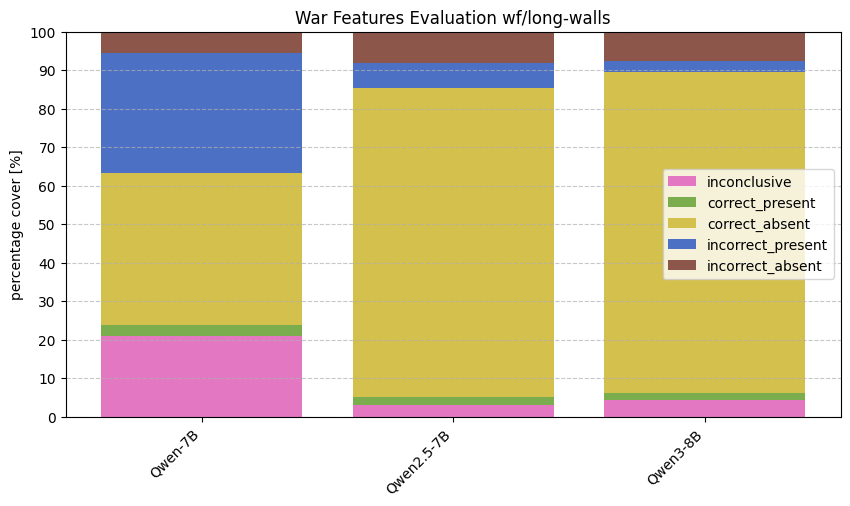

Attempting dataset refresh. False
core/macro-regions https://seshat-db.com/api/core/macro-regions/
Ignoring polity core/macro-regions as per configuration.
core/regions https://seshat-db.com/api/core/regions/
Ignoring polity core/regions as per configuration.
core/ngas https://seshat-db.com/api/core/ngas/
Ignoring polity core/ngas as per configuration.
core/polities https://seshat-db.com/api/core/polities/
Ignoring polity core/polities as per configuration.
core/capitals https://seshat-db.com/api/core/capitals/
Ignoring polity core/capitals as per configuration.
core/nga-polity-relations https://seshat-db.com/api/core/nga-polity-relations/
Ignoring polity core/nga-polity-relations as per configuration.
core/sections https://seshat-db.com/api/core/sections/
Ignoring polity core/sections as per configuration.
core/subsections https://seshat-db.com/api/core/subsections/
Ignoring polity core/subsections as per configuration.
core/variable-hierarchies https://seshat-db.com/api/core/variable

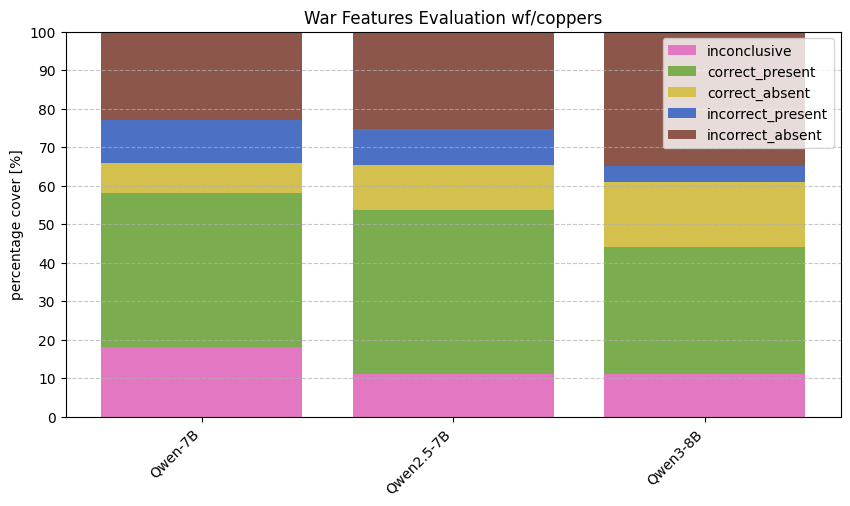

Attempting dataset refresh. False
core/macro-regions https://seshat-db.com/api/core/macro-regions/
Ignoring polity core/macro-regions as per configuration.
core/regions https://seshat-db.com/api/core/regions/
Ignoring polity core/regions as per configuration.
core/ngas https://seshat-db.com/api/core/ngas/
Ignoring polity core/ngas as per configuration.
core/polities https://seshat-db.com/api/core/polities/
Ignoring polity core/polities as per configuration.
core/capitals https://seshat-db.com/api/core/capitals/
Ignoring polity core/capitals as per configuration.
core/nga-polity-relations https://seshat-db.com/api/core/nga-polity-relations/
Ignoring polity core/nga-polity-relations as per configuration.
core/sections https://seshat-db.com/api/core/sections/
Ignoring polity core/sections as per configuration.
core/subsections https://seshat-db.com/api/core/subsections/
Ignoring polity core/subsections as per configuration.
core/variable-hierarchies https://seshat-db.com/api/core/variable

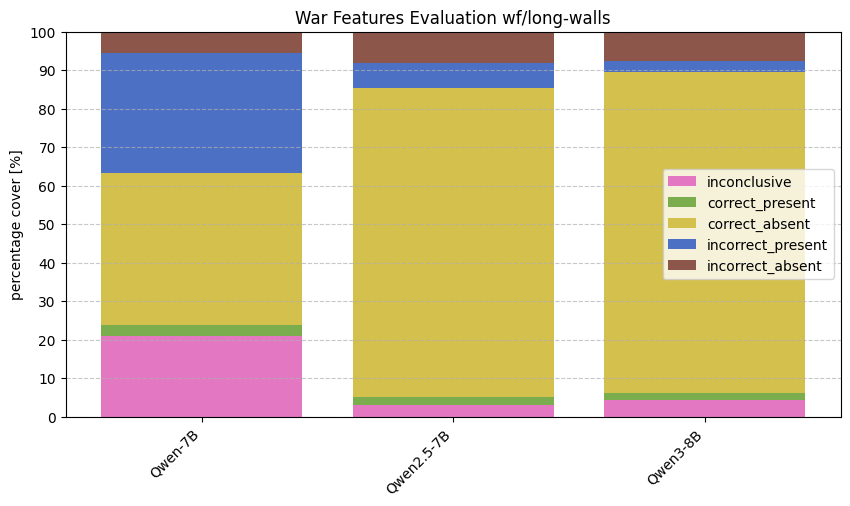

Attempting dataset refresh. False
core/macro-regions https://seshat-db.com/api/core/macro-regions/
Ignoring polity core/macro-regions as per configuration.
core/regions https://seshat-db.com/api/core/regions/
Ignoring polity core/regions as per configuration.
core/ngas https://seshat-db.com/api/core/ngas/
Ignoring polity core/ngas as per configuration.
core/polities https://seshat-db.com/api/core/polities/
Ignoring polity core/polities as per configuration.
core/capitals https://seshat-db.com/api/core/capitals/
Ignoring polity core/capitals as per configuration.
core/nga-polity-relations https://seshat-db.com/api/core/nga-polity-relations/
Ignoring polity core/nga-polity-relations as per configuration.
core/sections https://seshat-db.com/api/core/sections/
Ignoring polity core/sections as per configuration.
core/subsections https://seshat-db.com/api/core/subsections/
Ignoring polity core/subsections as per configuration.
core/variable-hierarchies https://seshat-db.com/api/core/variable

TypeError: unsupported operand type(s) for +=: 'zip' and 'zip'

In [ ]:
import os

from typing import Dict, List, Any

from llm_benchmark.utils.dataset import Dataset, DatasetModule
from llm_benchmark.utils import benchmark
from llm_benchmark.data import eval
from llm_benchmark.display import plotting

def tally_single_model(answer_suffix: str
                       ) -> Dict[str, object]:
    dataset: Dataset = benchmark.seshat_setup(seshat_cache_dir="/Users/apple/Documents/github/neurips_llms/llm-bechmark/db/seshat", force=False)
    tally_all: List[Dict[str, Any]] = eval.tally_directory(dataset=dataset, dir=os.path.join("/Users/apple/Documents/github/neurips_llms/llm-bechmark/db/evaluation/", answer_suffix, "wf_answers"))

    data: Dict[str, object] = {}
    for endpoint, data_single in tally_all.items():
        counts, strings = zip(*data_single.values())
        data.update({endpoint.replace("_answers", ""): zip(data_single.keys(), counts)})
    return data

def timeseries_single(endpoint: str
                      ) -> Dict[str, object]:
    data_Qwen_7B: Dict[str, object] = tally_single_model(answer_suffix="22_04_2026/run_3_Qwen_Qwen-7B-Chat")
    data_Qwen3_8B: Dict[str, object] = tally_single_model(answer_suffix="14_05_2026/run_9_Qwen_Qwen3-8B")
    data_Qwen2_5_7B: Dict[str, object] = tally_single_model(answer_suffix="14_05_2026/run_11_Qwen_Qwen2.5-7B")

    datasets: Dict[str, object] = [("Qwen-7B", data_Qwen_7B), ("Qwen2.5-7B", data_Qwen2_5_7B), ("Qwen3-8B", data_Qwen3_8B)]

    data: Dict[str, object] = {}

    for model, (dataset) in datasets:
        for ep, data_single in dataset.items():
            if ep == endpoint:
                data.update({model: data_single})
    return data


def plot_single_endpoint(endpoint: str, plot_absolute: bool = False, plot_relative: bool = True, figsize: tuple = (20, 6)) -> None:
    data_split: Dict[str, object] = timeseries_single(endpoint=endpoint)
    
    if plot_relative:
        plotting.plot_stacked_bar_chart(
            data=data_split,
            figsize=figsize,
            title="War Features Evaluation " + endpoint,
            absolute=False,
            y_limits=[0, 100],
            y_label="percentage cover [%]"
        )
    if plot_absolute:
        plotting.plot_stacked_bar_chart(
            data=data_split,
            figsize=figsize,
            title="War Features Evaluation " + endpoint,
            absolute=True,
            y_limits=[0, 400],
            y_label="n, absolute count [-]"
        )


plot_absolute: bool = False
plot_relative: bool = True

figsize: tuple = (10, 5)

plot_single_endpoint(endpoint="wf/long-walls", plot_absolute=plot_absolute, plot_relative=plot_relative, figsize=figsize)
plot_single_endpoint(endpoint="wf/coppers", plot_absolute=plot_absolute, plot_relative=plot_relative, figsize=figsize)
plot_single_endpoint(endpoint="wf/long-walls", plot_absolute=plot_absolute, plot_relative=plot_relative, figsize=figsize)


datapoints = [timeseries_single(endpoint="wf/long-walls"), timeseries_single(endpoint="wf/coppers")]

aggregate: Dict[str, object] = {}

for dp in datapoints:
    for model, data in dp.items():
        if model in aggregate:
            aggregate[model](data)
        else:
            aggregate[model] = data



print(datapoints)

if plot_relative:
    plotting.plot_stacked_bar_chart(
        data=aggregate,
        figsize=figsize,
        title="War Features Evaluation ",
        absolute=False,
        y_limits=[0, 100],
        y_label="percentage cover [%]"
    )
if plot_absolute:
    plotting.plot_stacked_bar_chart(
        data=aggregate,
        figsize=figsize,
        title="War Features Evaluation ",
        absolute=True,
        y_limits=[0, 400],
        y_label="n, absolute count [-]"
    )

